## Dataset Loading

The dataset used in this project is the **WM811K wafer defect dataset**, which contains wafer maps produced during semiconductor manufacturing testing. Each wafer map represents the spatial layout of dies (individual chips) on a wafer and whether each die passed or failed electrical testing.

The dataset was exported as a CSV file. Each row contains:

- `waferMap`: a grid representing pass/fail chip locations
- `dieSize`: the size of the dies on the wafer
- `lotName`: the manufacturing lot identifier
- `waferIndex`: the wafer number within the lot
- `trianTestLabel`: indicates whether the wafer belongs to the training or testing set
- `failureType`: the defect pattern classification

We first load the dataset into a pandas DataFrame so that it can be explored and processed.

In [2]:

import pandas as pd
import numpy as np
from pathlib import Path

# Prefer the NPZ wafer arrays + metadata CSV because the CSV export may
# contain abbreviated wafer-map strings with ellipses that cannot be parsed.
notebook_dir = Path.cwd()
repo_root = notebook_dir if (notebook_dir / "LSWMD.pkl").exists() else notebook_dir.parent
analysis_dir = repo_root / "WM811K_data_and_analysis"
if not analysis_dir.exists():
    analysis_dir = notebook_dir

npz_path = analysis_dir / "wm811k_wafer_maps.npz"
metadata_path = analysis_dir / "wm811k_metadata.csv"
csv_path = analysis_dir / "wm811K_csv_export.csv"
pickle_path = repo_root / "LSWMD.pkl"

if npz_path.exists() and metadata_path.exists():
    metadata = pd.read_csv(metadata_path)
    wafer_maps = np.load(npz_path, allow_pickle=True)["wafer_maps"]
    df = metadata.copy()
    df.insert(0, "waferMap", list(wafer_maps))
    print(f"Loaded wafer maps from: {npz_path}")
    print(f"Loaded metadata from: {metadata_path}")
elif csv_path.exists():
    df = pd.read_csv(csv_path)
    print(f"Loaded CSV data from: {csv_path}")
elif pickle_path.exists():
    df = pd.read_pickle(pickle_path)
    print(f"Loaded pickle data from: {pickle_path}")
else:
    raise FileNotFoundError(
        "Could not find wm811k_wafer_maps.npz + wm811k_metadata.csv, "
        "wm811K_csv_export.csv, or LSWMD.pkl. Download the WM811K dataset "
        "and place it in the repo before running this notebook."
    )

print(df.head())
print(df.info())


Loaded wafer maps from: x:\ECEsite\Machine-Learning-Class-Repo\WM811K_data_and_analysis\wm811k_wafer_maps.npz
Loaded metadata from: x:\ECEsite\Machine-Learning-Class-Repo\WM811K_data_and_analysis\wm811k_metadata.csv
                                            waferMap  dieSize lotName  \
0  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
1  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
2  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
3  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
4  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   

   waferIndex  trianTestLabel failureType  
0         1.0  [['Training']]  [['none']]  
1         2.0  [['Training']]  [['none']]  
2         3.0  [['Training']]  [['none']]  
3         4.0  [['Training']]  [['none']]  
4         5.0  [['Training']]  [['none']]  
<class 'pandas.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (

## Converting Wafer Maps into Numerical Arrays

In the CSV file, the wafer maps are stored as text strings representing matrices. For machine learning, these maps must be converted into numerical arrays.

The `parse_wafer_map` function extracts each row of numbers from the string representation and reconstructs the wafer map as a two‑dimensional NumPy array. This allows the wafer data to be treated as image-like spatial data for later machine learning models.

In [3]:

import numpy as np
import re
from collections import Counter

def parse_wafer_map(value):
    """Return a wafer map as a rectangular 2D NumPy array.

    CSV exports store wafer maps as strings and may contain abbreviated
    rows with ellipses. The original pickle stores maps as arrays/lists.
    Malformed or non-rectangular maps return an empty array and are
    removed by the validation step.
    """
    if isinstance(value, np.ndarray):
        return value

    if isinstance(value, (list, tuple)):
        arr = np.array(value)
        return arr if arr.ndim == 2 else np.array([])

    if not isinstance(value, str):
        return np.array([])

    rows = []
    for line in value.strip().splitlines():
        if "..." in line:
            continue
        line = line.strip().strip("[]")
        numbers = [int(x) for x in re.findall(r"\d+", line)]
        if numbers:
            rows.append(numbers)

    if not rows:
        matches = re.findall(r"\[([0-9\s]+)\]", value)
        rows = [[int(x) for x in row.split()] for row in matches]

    if not rows:
        return np.array([])

    lengths = [len(row) for row in rows]
    most_common_len, count = Counter(lengths).most_common(1)[0]
    rectangular_rows = [row for row in rows if len(row) == most_common_len]

    if most_common_len == 0 or len(rectangular_rows) < 2:
        return np.array([])

    return np.array(rectangular_rows, dtype=int)


In [4]:
df["waferMap"] = df["waferMap"].apply(parse_wafer_map)

In [5]:
print(type(df["waferMap"][0]))
print(df["waferMap"][0].shape)
print(df["waferMap"][0])

<class 'numpy.ndarray'>
(45, 48)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


## Cleaning Label Fields

The dataset stores some fields such as `failureType` and `trianTestLabel` with additional brackets and quotation marks. These characters are removed using regular expressions so that the labels are stored as simple categorical values.

This step ensures that the defect types can later be used as classification labels.

In [6]:

def clean_label(value):
    """Convert CSV-style or pickle-style labels into plain strings."""
    if isinstance(value, str):
        return value.replace("[", "").replace("]", "").replace("'", "").replace('"', "").strip()

    arr = np.array(value, dtype=object).ravel()
    if len(arr) == 0:
        return ""

    item = arr[0]
    if item is None:
        return ""

    return str(item).replace("[", "").replace("]", "").replace("'", "").replace('"', "").strip()

df["failureType"] = df["failureType"].apply(clean_label)
df["trianTestLabel"] = df["trianTestLabel"].apply(clean_label)

# remove unlabeled wafers
df = df[df["failureType"] != ""]


## Validating Wafer Maps

Some entries in the dataset may contain malformed wafer maps or arrays that are not valid two-dimensional grids. Before training machine learning models, we verify that each wafer map:

- is a two-dimensional array
- contains valid numerical values
- has non-zero dimensions

Invalid wafer maps are removed to ensure the dataset is consistent and suitable for analysis.

In [7]:
print(df["failureType"].value_counts())

failureType
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


## Standardizing Wafer Map Dimensions

Wafer maps in the dataset can have slightly different grid sizes depending on the manufacturing configuration. However, machine learning models require consistent input dimensions.

To address this, each wafer map is standardized to a fixed size of **26 × 26**. If a wafer is smaller than this size, it is padded with zeros. If it is larger, it is cropped.

This ensures that all samples have identical dimensions and can be combined into a single dataset tensor.

In [8]:
from skimage.transform import resize
def valid_map(w):
    w = np.array(w)
    return w.ndim == 2 and w.shape[0] > 0 and w.shape[1] > 0

df = df[df["waferMap"].apply(valid_map)]
def standardize_wafer(w, target_size=26):

    w = np.array(w)

    # remove NaN values if they exist
    w = np.nan_to_num(w)

    # ensure it is 2D
    if w.ndim != 2:
        return None

    h, w_ = w.shape

    new = np.zeros((target_size, target_size))

    h_min = min(h, target_size)
    w_min = min(w_, target_size)

    new[:h_min, :w_min] = w[:h_min, :w_min]

    return new
df["waferMap"] = df["waferMap"].apply(standardize_wafer)


## Constructing the Machine Learning Dataset

After preprocessing the wafer maps, the data is separated into:

- **X**: the input wafer maps (features)
- **y**: the defect labels (target variable)

The wafer maps are stacked into a three-dimensional NumPy array where each entry corresponds to a wafer image. This format is suitable for both classical machine learning algorithms and deep learning models.

In [9]:
X = np.stack(df["waferMap"].values)
y = df["failureType"].values

print(X.shape)

(172950, 26, 26)


In [10]:
print(X.shape)
print(y.shape)

(172950, 26, 26)
(172950,)


## Encoding Defect Labels

Machine learning models require numerical labels rather than text categories. The `LabelEncoder` from scikit‑learn converts each defect type into a unique integer value.

For example:

- Center → 0
- Donut → 1
- Edge-Loc → 2
- Edge-Ring → 3
- Scratch → 4

This allows the classification algorithms to learn patterns associated with each defect category.

In [11]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

## Splitting the Dataset

To evaluate model performance properly, the dataset is divided into:

- **Training set (80%)** – used to train the models
- **Test set (20%)** – used to evaluate performance on unseen data

This prevents the model from simply memorizing the dataset and provides a more realistic estimate of real-world performance.

In [12]:
from sklearn.model_selection import train_test_split

X = X.astype("float32") / 2.0
X = X[..., np.newaxis]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)


In [13]:
X_train_flat = X_train_full.reshape(len(X_train_full), -1)
X_test_flat = X_test.reshape(len(X_test), -1)


## Baseline Model: Random Forest Classifier

Before applying deep learning, we first train a traditional machine learning model as a baseline.

A **Random Forest classifier** is used because it performs well on many classification tasks and requires minimal feature engineering. Since classical models expect one-dimensional input vectors, each wafer map is flattened into a single feature vector.

The performance of this baseline model provides a reference point for evaluating the effectiveness of the convolutional neural network introduced later.

In [14]:

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, n_jobs=-1)

rf.fit(X_train_flat, y_train_full)

rf_pred = rf.predict(X_test_flat)


## Model Evaluation

After training, the model is evaluated using the test dataset.

Two evaluation methods are used:

- **Classification report** – provides precision, recall, and F1-score for each defect class
- **Confusion matrix** – visualizes how often each class is correctly or incorrectly predicted

The confusion matrix helps identify which defect types are easily recognized and which are frequently misclassified.

In [15]:

from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))


              precision    recall  f1-score   support

           0       0.95      0.73      0.82       859
           1       0.88      0.51      0.65       111
           2       0.79      0.30      0.44      1038
           3       0.99      0.89      0.94      1936
           4       0.74      0.19      0.30       718
           5       0.92      0.77      0.84        30
           6       0.87      0.50      0.63       173
           7       0.63      0.11      0.19       239
           8       0.94      1.00      0.97     29486

    accuracy                           0.94     34590
   macro avg       0.86      0.56      0.64     34590
weighted avg       0.93      0.94      0.93     34590



## Convolutional Neural Network (CNN)

Wafer maps contain spatial patterns that resemble images. Convolutional Neural Networks (CNNs) are particularly effective for learning spatial features such as clusters, rings, and scratches that occur in wafer defect patterns.

The CNN architecture used in this project consists of:

- Convolutional layers that extract spatial features
- Max-pooling layers that reduce spatial dimensionality
- Fully connected layers that perform classification

The final layer uses a softmax activation function to predict the probability of each defect class.

In [16]:
# OLD CNN MODEL 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from sklearn.model_selection import train_test_split


old_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(26,26,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(len(np.unique(y_encoded)), activation='softmax')
])

old_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# compute class weights
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# convert to dictionary format
class_weights = dict(zip(np.unique(y_train), weights))

print(class_weights)  #just to see values

{np.int64(0): np.float64(4.4754973313925275), np.int64(1): np.float64(34.64413145539906), np.int64(2): np.float64(3.703302218207367), np.int64(3): np.float64(1.9852569276298089), np.int64(4): np.float64(5.3472463768115945), np.int64(5): np.float64(129.459649122807), np.int64(6): np.float64(22.15975975975976), np.int64(7): np.float64(16.118829183049368), np.int64(8): np.float64(0.13034323908036233)}


x:\ECEsite\Machine-Learning-Class-Repo\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
#training the old model
old_history = old_model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=64,
    validation_data=(X_val, y_val),
    class_weight=class_weights
)

Epoch 1/40


1730/1730 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.4536 - loss: 1.3642 - val_accuracy: 0.8566 - val_loss: 0.9736
Epoch 2/40
1730/1730 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6793 - loss: 0.9052 - val_accuracy: 0.4356 - val_loss: 1.3092
Epoch 3/40
1730/1730 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7476 - loss: 0.7723 - val_accuracy: 0.8491 - val_loss: 0.6571
Epoch 4/40
1730/1730 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7719 - loss: 0.6728 - val_accuracy: 0.6900 - val_loss: 0.9452
Epoch 5/40
1730/1730 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7849 - loss: 0.6029 - val_accuracy: 0.7026 - val_loss: 0.9036
Epoch 6/40
1730/1730 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7967 - loss: 0.5240 - val_accuracy: 0.8786 - val_loss: 0.5086
Epoch 7/40
1730/1730 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8089 - loss: 0.4982 - val_accuracy: 0.7577 - val_loss: 0.7432
Epoch 8/40
1730/1730 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8074 - loss: 0.4181 - val

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Input(shape=(26, 26, 1)),

    Conv2D(32, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),

    GlobalAveragePooling2D(),

    Dense(128, activation="relu"),
    Dropout(0.4),

    Dense(len(np.unique(y_encoded)), activation="softmax")
])

model.compile(
    optimizer=Adam(learning_rate=0.0002),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [19]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    patience=5,
    restore_best_weights=True,
    monitor="val_loss",
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

print(history.history["val_loss"])


Epoch 1/40
1730/1730 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - accuracy: 0.5746 - loss: 1.3168 - val_accuracy: 0.6610 - val_loss: 1.2108 - learning_rate: 2.0000e-04
Epoch 2/40
1730/1730 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - accuracy: 0.6860 - loss: 0.9645 - val_accuracy: 0.7614 - val_loss: 0.9254 - learning_rate: 2.0000e-04
Epoch 3/40
1730/1730 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - accuracy: 0.7306 - loss: 0.8519 - val_accuracy: 0.4730 - val_loss: 1.4885 - learning_rate: 2.0000e-04
Epoch 4/40
1730/1730 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - accuracy: 0.7584 - loss: 0.7635 - val_accuracy: 0.8849 - val_loss: 0.4953 - learning_rate: 2.0000e-04
Epoch 5/40
1730/1730 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - accuracy: 0.7633 - loss: 0.7026 - val_accuracy: 0.8306 - val_loss: 0.6423 - learning_rate: 2.0000e-04
Epoch 6/40
1730/1730 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - accuracy: 0.7826 - loss: 0.6566 - val_accuracy: 0.6767 - val_loss: 1.0715 - learning_rate: 2.0000e-04
Epoch 7/40
1728/1730 ━━━━━━━━━━━━━━━━━━━

In [20]:
# OLD CNN predictions
old_preds = old_model.predict(X_test)
old_preds = np.argmax(old_preds, axis=1)

# NEW CNN predictions
cnn_preds = model.predict(X_test)
cnn_preds = np.argmax(cnn_preds, axis=1)

1081/1081 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


In [21]:

#compute metrics for diff models
from sklearn.metrics import accuracy_score, f1_score

# Random Forest
rf_acc = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred, average='weighted')

# OLD CNN
cnn_old_acc = accuracy_score(y_test, old_preds)
cnn_old_f1 = f1_score(y_test, old_preds, average='weighted')

# NEW CNN
cnn_acc = accuracy_score(y_test, cnn_preds)
cnn_f1 = f1_score(y_test, cnn_preds, average='weighted')


In [22]:
#comparison of models

print(X_train.shape)
print(X_test.shape)
print(y_train[:10])
print(y_test[:10])
print(cnn_preds[:20])

import pandas as pd

results = pd.DataFrame({
    "Model": ["Random Forest", "CNN (Old)", "CNN (Improved)"],
    "Accuracy": [rf_acc, cnn_old_acc, cnn_acc],
    "F1 Score": [rf_f1, cnn_old_f1, cnn_f1]
})

# make it look nice
results["Accuracy"] = results["Accuracy"].round(4)
results["F1 Score"] = results["F1 Score"].round(4)

results

(110688, 26, 26, 1)
(34590, 26, 26, 1)
[8 8 7 3 8 0 8 8 8 8]
[8 8 8 8 8 8 8 8 8 8]
[8 8 8 8 8 8 8 8 8 8 3 3 8 8 8 8 1 8 8 8]


,Model,Accuracy,F1 Score
0,Random Forest,0.9389,0.9256
1,CNN (Old),0.8941,0.9080
2,CNN (Improved),0.8793,0.9004


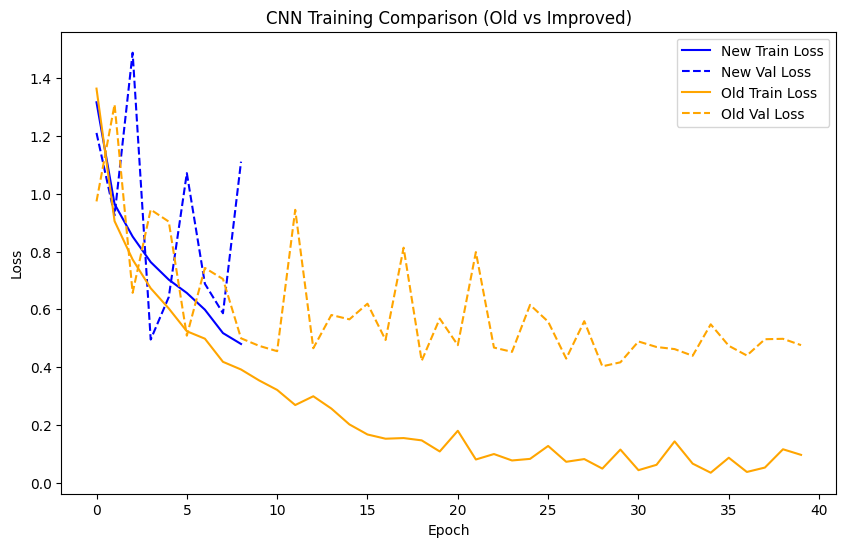

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# NEW MODEL
plt.plot(history.history['loss'], label='New Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='New Val Loss', color='blue', linestyle='dashed')

# OLD MODEL
plt.plot(old_history.history['loss'], label='Old Train Loss', color='orange')
plt.plot(old_history.history['val_loss'], label='Old Val Loss', color='orange', linestyle='dashed')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training Comparison (Old vs Improved)")
plt.legend()

plt.show()

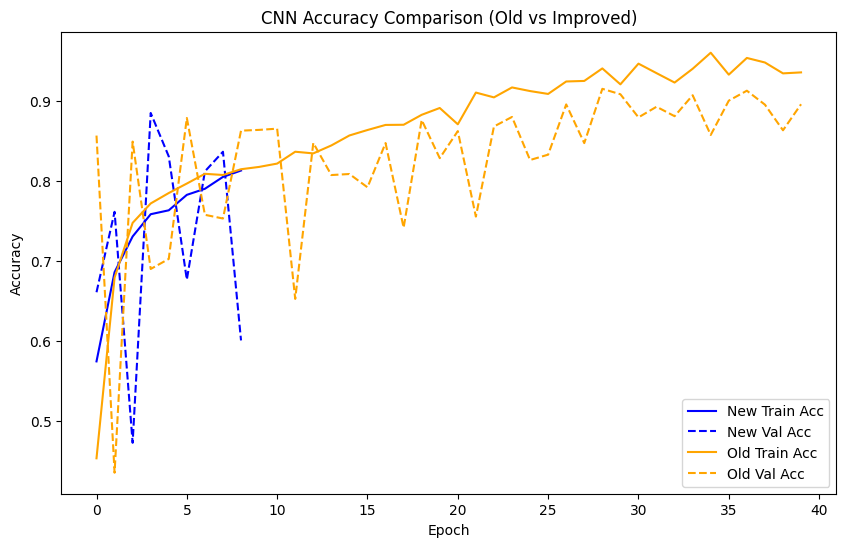

In [24]:
#accuracy comparison
plt.figure(figsize=(10,6))

# NEW MODEL
plt.plot(history.history['accuracy'], label='New Train Acc', color='blue')
plt.plot(history.history['val_accuracy'], label='New Val Acc', color='blue', linestyle='dashed')

# OLD MODEL
plt.plot(old_history.history['accuracy'], label='Old Train Acc', color='orange')
plt.plot(old_history.history['val_accuracy'], label='Old Val Acc', color='orange', linestyle='dashed')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy Comparison (Old vs Improved)")
plt.legend()

plt.show()

In [25]:

cnn_probs = model.predict(X_test)
cnn_preds = cnn_probs.argmax(axis=1)


1081/1081 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


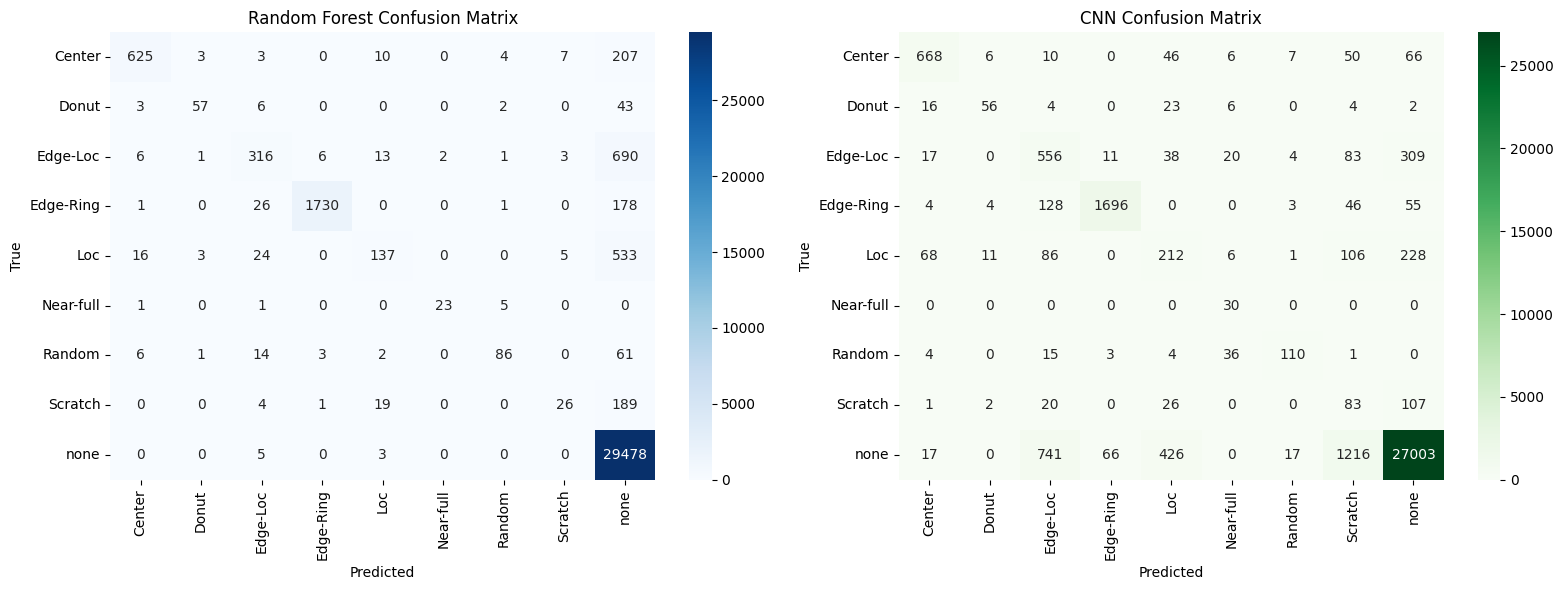

In [26]:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Random Forest confusion matrix
cm_rf = confusion_matrix(y_test, rf_pred)

# CNN confusion matrix
cm_cnn = confusion_matrix(y_test, cnn_preds)

class_names = encoder.classes_

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0]
)
axes[0].set_title("Random Forest Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

# CNN
sns.heatmap(
    cm_cnn,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1]
)
axes[1].set_title("CNN Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()


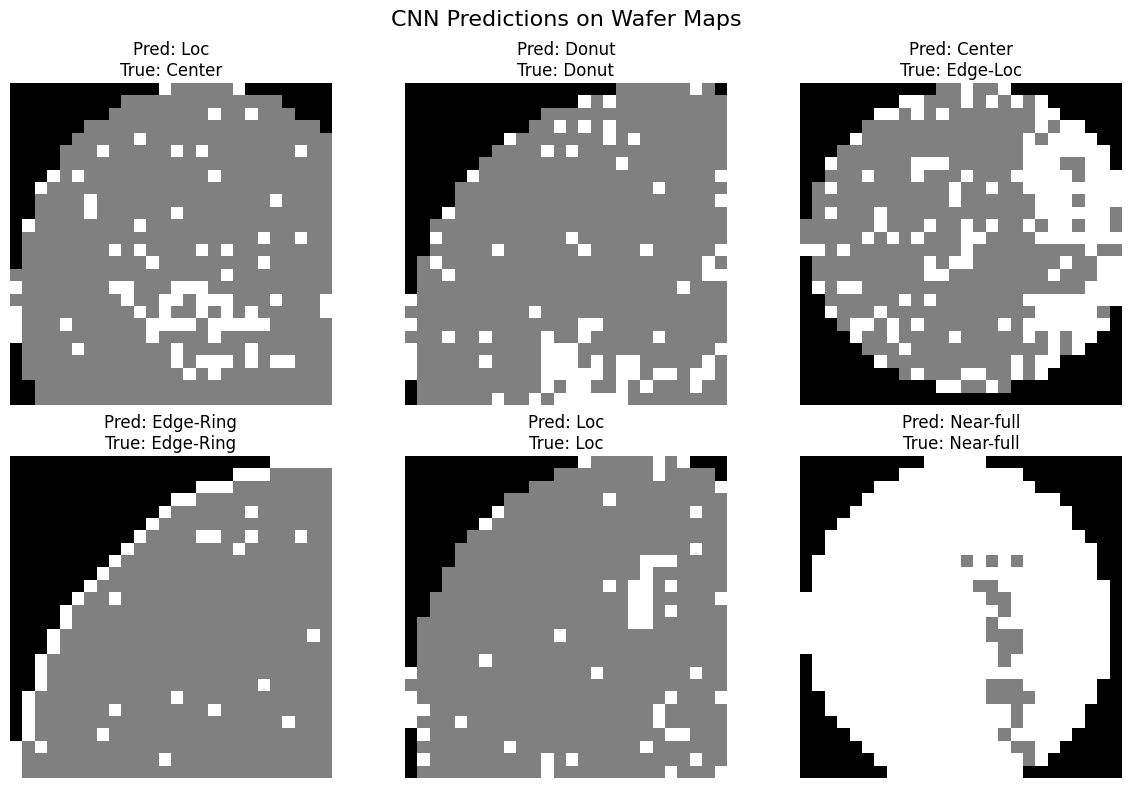

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# number of samples to show
num_samples = 6

indices = []

# pick one example from each class
for c in range(len(class_names)):
    for i in range(len(y_test)):
        if y_test[i] == c:
            indices.append(i)
            break

# limit to first 6 classes for display
indices = indices[:6]
plt.figure(figsize=(12, 8))

for i, idx in enumerate(indices):
    img = X_test[idx]
    true_label = y_test[idx]
    pred_label = cnn_preds[idx]

    plt.subplot(2, 3, i+1)
    plt.imshow(img.squeeze(), cmap="gray")

    plt.title(f"Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}")
    plt.axis("off")

plt.suptitle("CNN Predictions on Wafer Maps", fontsize=16)
plt.tight_layout()
plt.show()